In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("automobileEDA_dirty_training.csv")
display(data.head())
display(data.info())
display(data.shape)

,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,2025-01-01,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,02/01/2025,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,01-03-2025,1,122,ALFA-ROMERO,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,04-Jan-2025,2,164,audi,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2025-01-05,2,164,audi,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_date   203 non-null    object 
 1   symboling          205 non-null    int64  
 2   normalized-losses  205 non-null    int64  
 3   make               203 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

None

(205, 30)

## EDA

In [6]:
data['symboling'].value_counts()
display(data['diesel'].value_counts())
display(data['gas'].value_counts())

,count
diesel,
0,184
1,21


,count
gas,
1,184
0,21


### Cleansing Data Categorical

In [5]:
data_raw = data.copy()
kolom_teks = data_raw.select_dtypes(include="object").columns
for c in kolom_teks:
  data_raw[c] = data_raw[c].astype("string").str.strip().str.lower()

data_raw.head()

,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,2025-01-01,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,medium,0,1
1,02/01/2025,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,medium,0,1
2,01-03-2025,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,medium,0,1
3,04-jan-2025,2,164,audi,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,medium,0,1
4,2025-01-05,2,164,audi,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,medium,0,1


In [10]:
kolom_number = data_raw.select_dtypes(include="number").columns
kolom_number = list(kolom_number)
kolom_number.remove('symboling')
kolom_number.remove('diesel')
kolom_number.remove('gas')

for c in kolom_number:
  data_raw[c] = data_raw[c].fillna(data_raw[c].median())

for c in kolom_teks:
  data_raw[c] = data_raw[c].fillna(data_raw[c].mode()[0])

data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_date   205 non-null    string 
 1   symboling          205 non-null    int64  
 2   normalized-losses  205 non-null    int64  
 3   make               205 non-null    string 
 4   aspiration         205 non-null    string 
 5   num-of-doors       205 non-null    string 
 6   body-style         205 non-null    string 
 7   drive-wheels       205 non-null    string 
 8   engine-location    205 non-null    string 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    string 
 15  num-of-cylinders   205 non-null    string 
 16  engine-size        205 non

In [14]:
data_raw['transaction_date'] = pd.to_datetime(data_raw['transaction_date'], dayfirst=True, format='mixed')
display(data_raw[['transaction_date']].head())


,transaction_date
0,2025-01-01
1,2025-01-02
2,2025-03-01
3,2025-01-04
4,2025-01-05


In [18]:
data_raw[data_raw.duplicated(keep=False)]
data_raw = data_raw.drop_duplicates()
data_raw.shape

(201, 30)

### Normalisasi

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_raw[kolom_number] = scaler.fit_transform(data_raw[kolom_number])

# Display the scaled data
display(data_raw[kolom_number].head())
data_raw[kolom_number].describe()

/tmp/ipykernel_1572/3860148816.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_raw[kolom_number] = scaler.fit_transform(data_raw[kolom_number])


,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km
0,0.298429,0.058309,0.413433,0.324786,0.083333,0.411171,0.260377,0.664286,0.290476,0.1250,0.294393,0.346939,0.222222,0.289474,0.207959,0.481481
1,0.298429,0.058309,0.413433,0.324786,0.083333,0.411171,0.260377,0.664286,0.290476,0.1250,0.294393,0.346939,0.222222,0.289474,0.282558,0.481481
2,0.298429,0.230321,0.449254,0.444444,0.383333,0.517843,0.343396,0.100000,0.666667,0.1250,0.495327,0.346939,0.166667,0.263158,0.282558,0.570175
3,0.518325,0.384840,0.529851,0.504274,0.541667,0.329325,0.181132,0.464286,0.633333,0.1875,0.252336,0.551020,0.305556,0.368421,0.219254,0.376157
4,0.518325,0.373178,0.529851,0.521368,0.541667,0.518231,0.283019,0.464286,0.633333,0.0625,0.313084,0.551020,0.138889,0.157895,0.306142,0.621914


,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.298429,0.355598,0.494045,0.477697,0.497222,0.414145,0.248587,0.564780,0.565506,0.197767,0.258765,0.394965,0.338308,0.386489,0.199809,0.387638
std,0.167520,0.176862,0.183913,0.179613,0.203985,0.200658,0.156781,0.191480,0.150515,0.250310,0.173893,0.195148,0.178423,0.179346,0.197076,0.190844
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.188482,0.230321,0.383582,0.324786,0.350000,0.264158,0.139623,0.435714,0.495238,0.100000,0.102804,0.265306,0.166667,0.236842,0.066283,0.228704
50%,0.298429,0.303207,0.479104,0.444444,0.525000,0.359193,0.222642,0.550000,0.580952,0.125000,0.219626,0.398110,0.305556,0.368421,0.129140,0.376157
75%,0.376963,0.460641,0.632836,0.538462,0.641667,0.557797,0.301887,0.742857,0.638095,0.150000,0.317757,0.551020,0.472222,0.473684,0.282558,0.570175
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


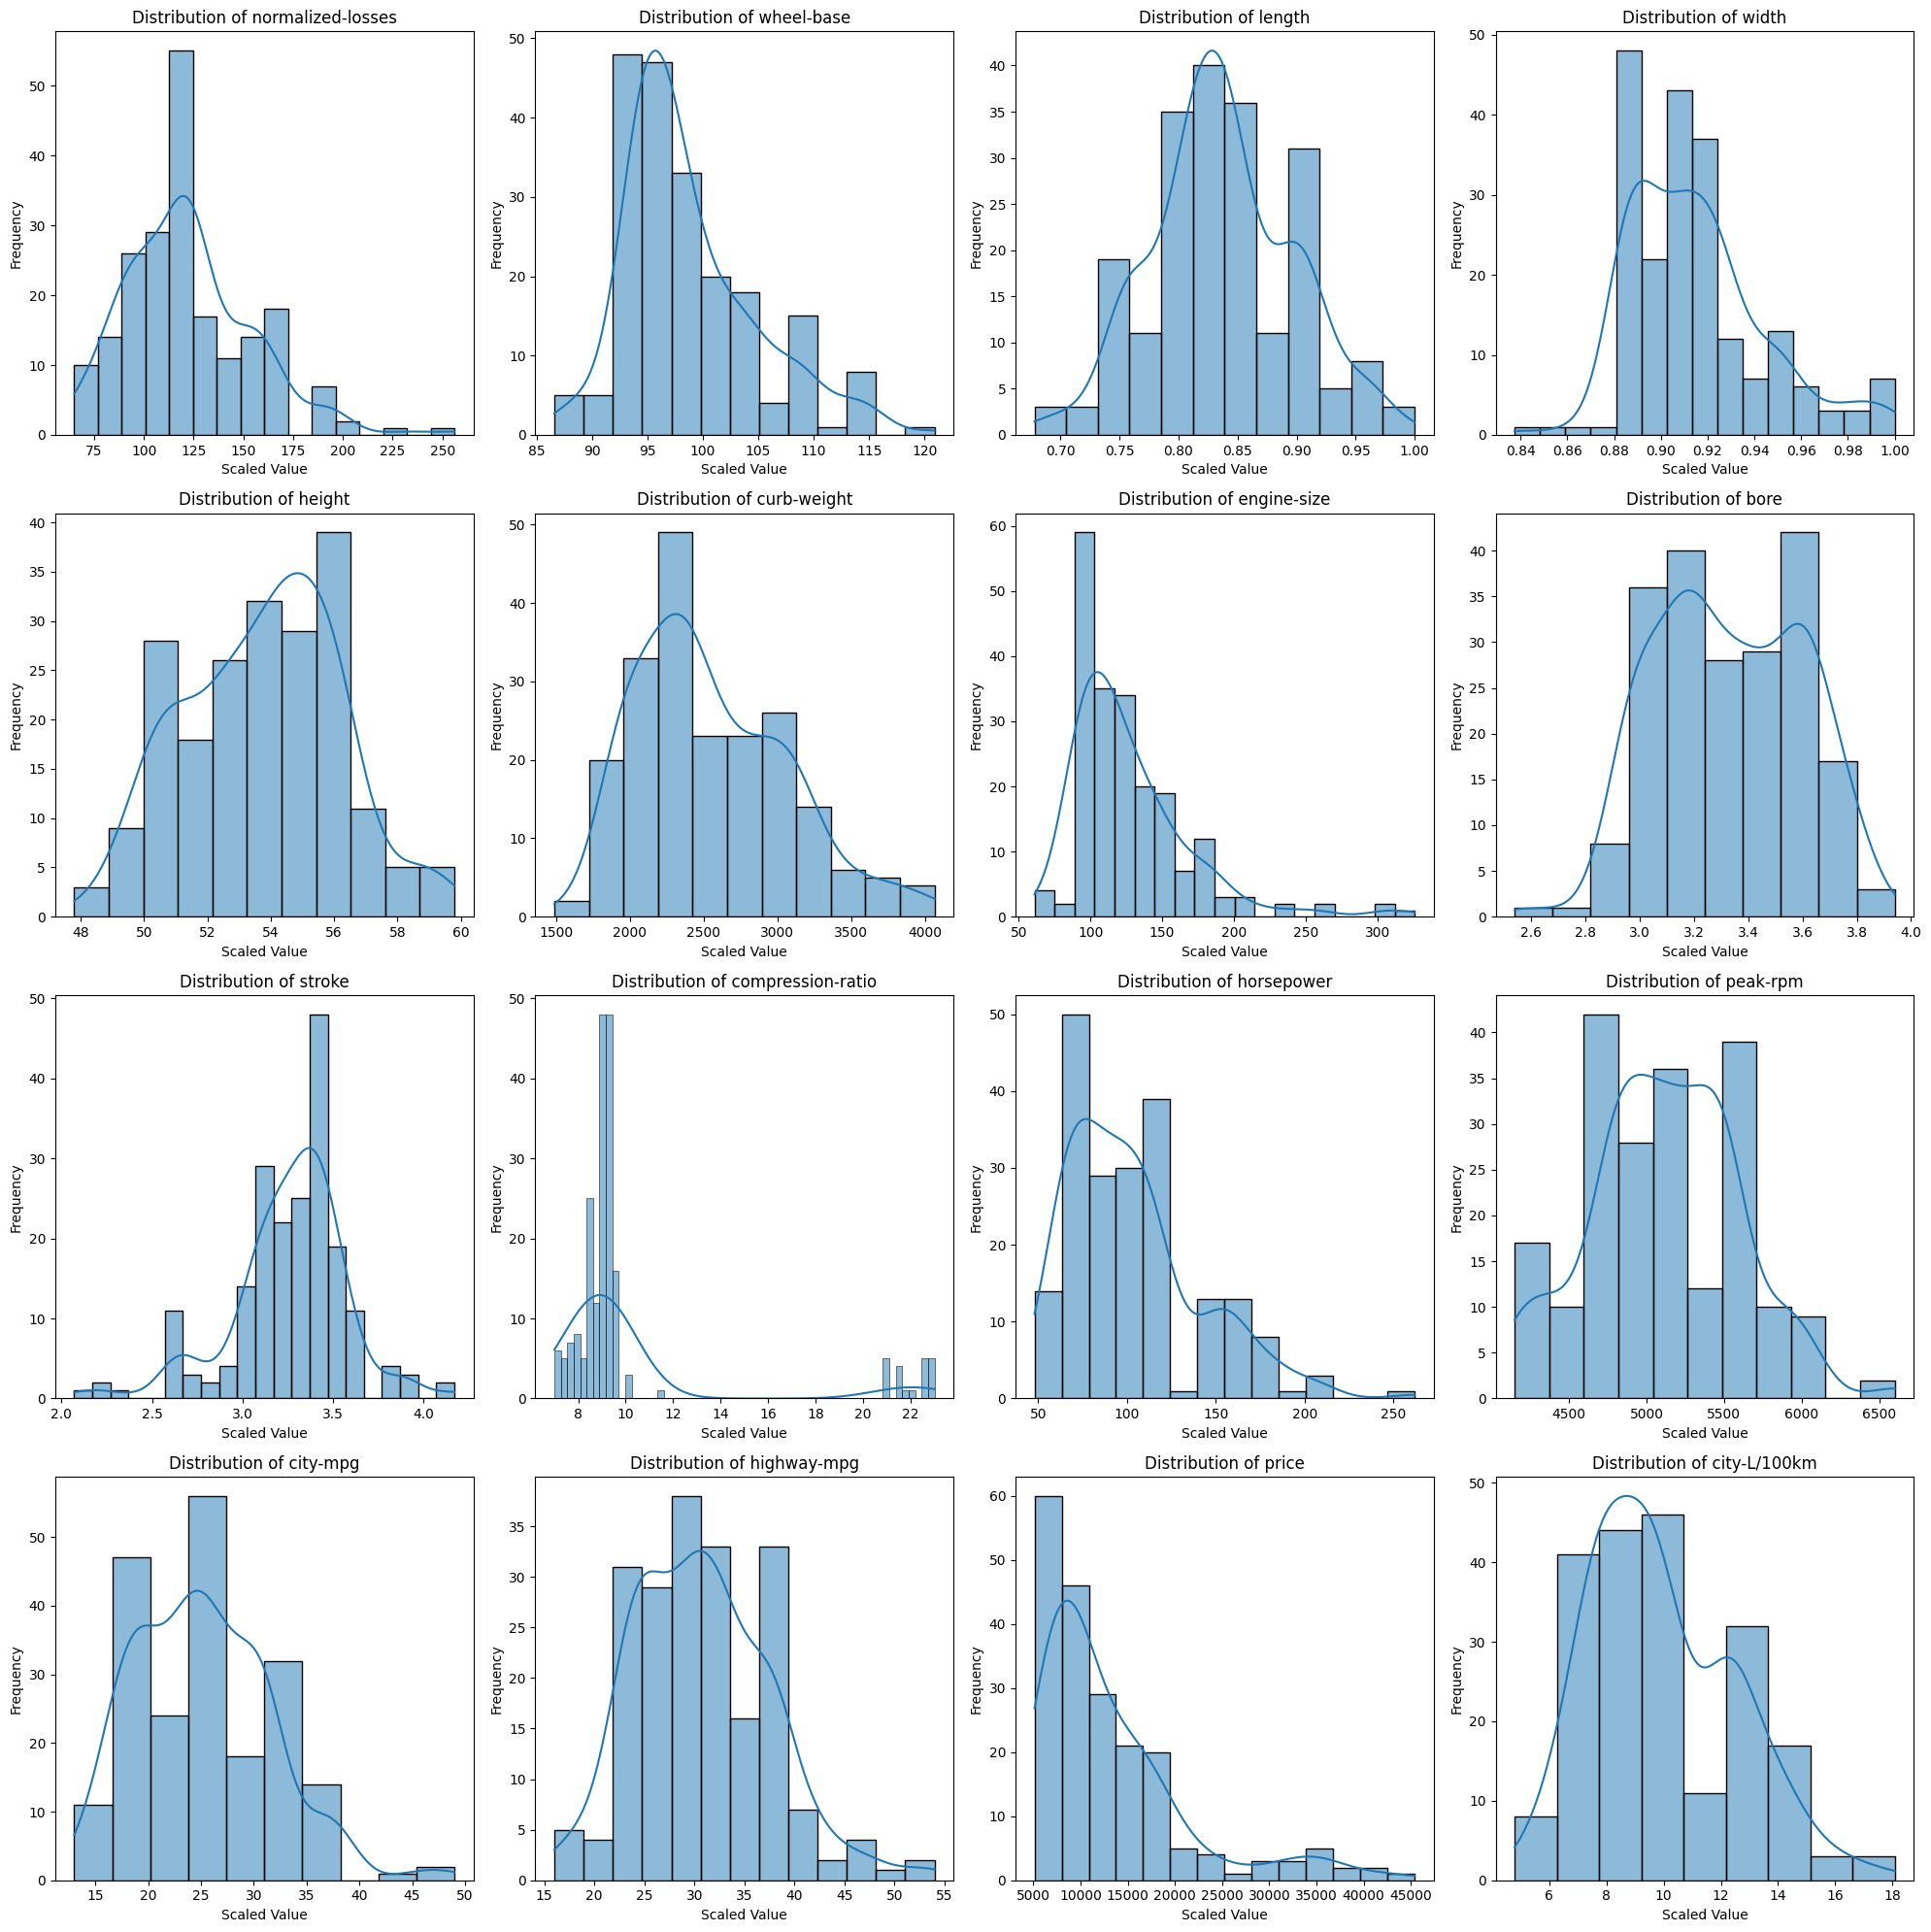

In [22]:
n_cols = 4
n_rows = (len(kolom_number) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(kolom_number):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel('Scaled Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

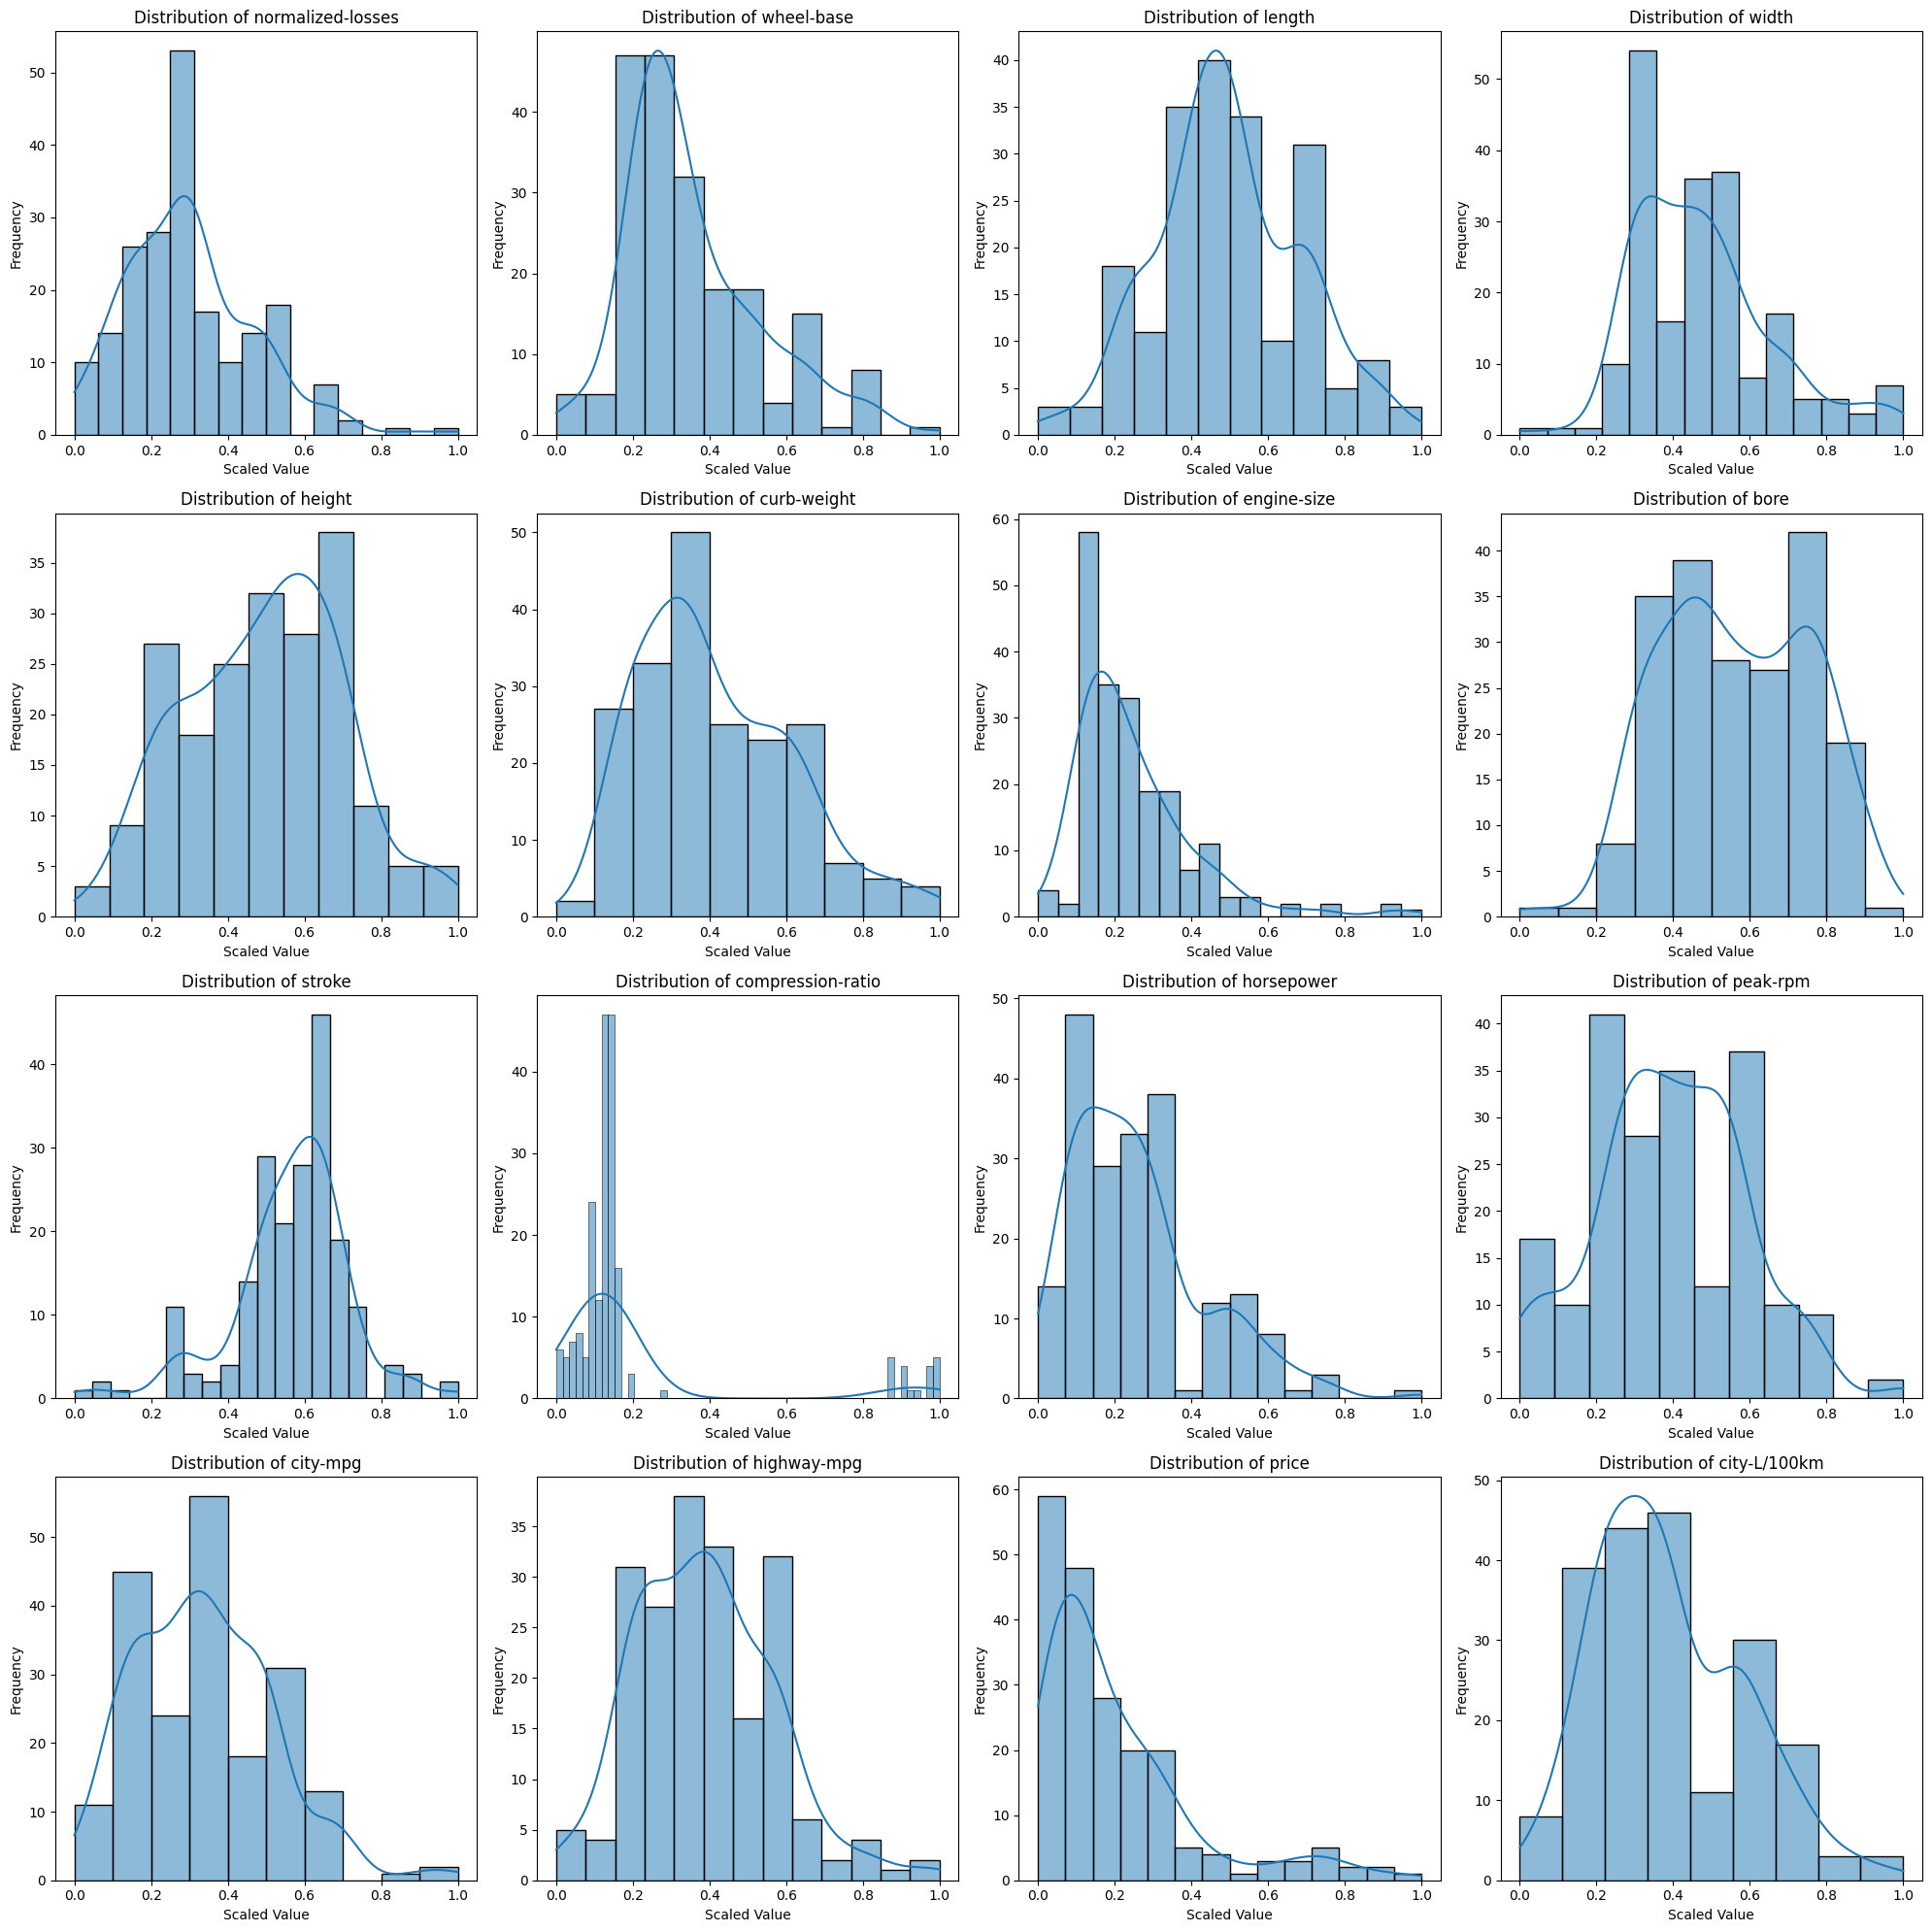

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the number of columns for the subplot grid
n_cols = 4
n_rows = (len(kolom_number) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(kolom_number):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(data_raw[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel('Scaled Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Encoding

In [24]:
for c in kolom_teks:
  display(data_raw[c].value_counts())

,count
transaction_date,
2025-01-06,3
2025-01-04,2
2025-07-01,2
2025-03-01,2
2025-02-07,2
...,...
2025-07-16,1
2025-07-17,1
2025-07-18,1


,count
make,
toyota,34
mazda,17
nissan,17
mitsubishi,12
honda,12
subaru,12
volkswagen,12
volvo,11
peugot,10


,count
aspiration,
std,165
turbo,36


,count
num-of-doors,
four,116
two,85


,count
body-style,
sedan,94
hatchback,69
wagon,24
hardtop,8
convertible,6


...

,count
engine-location,
front,198
rear,3


,count
engine-type,
ohc,145
ohcf,15
ohcv,13
dohc,12
l,12
rotor,4


,count
num-of-cylinders,
four,157
six,24
five,10
eight,4
two,4
twelve,1
three,1


,count
fuel-system,
mpfi,94
2bbl,63
idi,19
1bbl,11
spdi,9
4bbl,3
mfi,1
spfi,1


,count
horsepower-binned,
low,116
medium,62
high,23


### Label Encoding

In [26]:
label_column = ["aspiration", "num-of-doors","engine-location","horsepower-binned",'num-of-cylinders']


In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in label_column:
    data_raw[col] = le.fit_transform(data_raw[col])

# Display the encoded columns to verify
display(data_raw[label_column].head())
data_raw.info()

,aspiration,num-of-doors,engine-location,horsepower-binned,num-of-cylinders
0,0,1,0,2,2
1,0,1,0,2,2
2,0,1,0,2,3
3,0,0,0,2,2
4,0,0,0,2,1


<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 0 to 200
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   transaction_date   201 non-null    datetime64[ns]
 1   symboling          201 non-null    int64         
 2   normalized-losses  201 non-null    float64       
 3   make               201 non-null    string        
 4   aspiration         201 non-null    int64         
 5   num-of-doors       201 non-null    int64         
 6   body-style         201 non-null    string        
 7   drive-wheels       201 non-null    string        
 8   engine-location    201 non-null    int64         
 9   wheel-base         201 non-null    float64       
 10  length             201 non-null    float64       
 11  width              201 non-null    float64       
 12  height             201 non-null    float64       
 13  curb-weight        201 non-null    float64       
 14  engine-type    

In [29]:
one_hot = ["body-style","drive-wheels"]

In [30]:
data_raw = pd.get_dummies(data_raw, columns=one_hot)

# Display the new columns generated by one-hot encoding
new_cols = [col for col in data_raw.columns if any(orig in col for orig in one_hot)]
display(data_raw[new_cols].head())
data_raw.info()

,body-style_convertible,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon,drive-wheels_4wd,drive-wheels_awd,drive-wheels_fwd,drive-wheels_rwd
0,True,False,False,False,False,False,False,False,True
1,True,False,False,False,False,False,False,False,True
2,False,False,True,False,False,False,False,False,True
3,False,False,False,True,False,False,False,True,False
4,False,False,False,True,False,True,False,False,False


<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 0 to 200
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   transaction_date        201 non-null    datetime64[ns]
 1   symboling               201 non-null    int64         
 2   normalized-losses       201 non-null    float64       
 3   make                    201 non-null    string        
 4   aspiration              201 non-null    int64         
 5   num-of-doors            201 non-null    int64         
 6   engine-location         201 non-null    int64         
 7   wheel-base              201 non-null    float64       
 8   length                  201 non-null    float64       
 9   width                   201 non-null    float64       
 10  height                  201 non-null    float64       
 11  curb-weight             201 non-null    float64       
 12  engine-type             201 non-null    string        


In [31]:
freq_encoding = ["make","engine-type","fuel-system"]

In [34]:
freq_encoding = ["make", "engine-type", "fuel-system"]

for col in freq_encoding:
    freq = data_raw[col].value_counts(normalize=True)
    data_raw[col] = data_raw[col].map(freq)

In [35]:
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 0 to 200
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   transaction_date        201 non-null    datetime64[ns]
 1   symboling               201 non-null    int64         
 2   normalized-losses       201 non-null    float64       
 3   make                    201 non-null    Float64       
 4   aspiration              201 non-null    int64         
 5   num-of-doors            201 non-null    int64         
 6   engine-location         201 non-null    int64         
 7   wheel-base              201 non-null    float64       
 8   length                  201 non-null    float64       
 9   width                   201 non-null    float64       
 10  height                  201 non-null    float64       
 11  curb-weight             201 non-null    float64       
 12  engine-type             201 non-null    Float64       


## Data Pipelining

In [36]:
scaler = MinMaxScaler()
label_column = ["aspiration", "num-of-doors","engine-location","horsepower-binned",'num-of-cylinders']
le = LabelEncoder()
one_hot = ["body-style","drive-wheels"]
freq_encoding = ["make","engine-type","fuel-system"]

def load_data(filename):
  data = pd.read_csv(filename)
  display(data.head())
  display(data.info())
  display(data.shape)

  return data

def data_cleansing(data_raw):
  kolom_teks = data_raw.select_dtypes(include="object").columns

  for c in kolom_teks:
    data_raw[c] = data_raw[c].astype("string").str.strip().str.lower()

  #Missing Value Handling
  kolom_number = data_raw.select_dtypes(include="number").columns
  kolom_number = list(kolom_number)
  kolom_number.remove('symboling')
  kolom_number.remove('diesel')
  kolom_number.remove('gas')

  for c in kolom_number:
    data_raw[c] = data_raw[c].fillna(data_raw[c].median())

  for c in kolom_teks:
    data_raw[c] = data_raw[c].fillna(data_raw[c].mode()[0])

  data_raw['transaction_date'] = pd.to_datetime(data_raw['transaction_date'], dayfirst=True, format='mixed')
  data_raw = data_raw.drop_duplicates()

  return data_raw

def transform_data(data_raw):
  data_raw[kolom_number] = scaler.fit_transform(data_raw[kolom_number])
  for col in label_column:
    data_raw[col] = le.fit_transform(data_raw[col])

  data_raw = pd.get_dummies(data_raw, columns=one_hot)

  for col in freq_encoding:
    freq = data_raw[col].value_counts(normalize=True)
    data_raw[col] = data_raw[col].map(freq)

  return data_raw

def save_data(data_raw):
  data_raw.to_csv("preprocessed_data.csv",index=False)

def main(filename):
  data_raw = load_data(filename)
  data_raw = data_cleansing(data_raw)
  data_raw = transform_data(data_raw)
  save_data(data_raw)



In [37]:
main("automobileEDA_dirty_training.csv")

,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,2025-01-01,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,02/01/2025,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,01-03-2025,1,122,ALFA-ROMERO,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,04-Jan-2025,2,164,audi,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2025-01-05,2,164,audi,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_date   203 non-null    object 
 1   symboling          205 non-null    int64  
 2   normalized-losses  205 non-null    int64  
 3   make               203 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

None

(205, 30)